# Ejercicio 3. Clasificación de prendas con TensorFlow: cada función y cada instrucción explicada

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 3: *Con base en la librería tensorflow, descargue el data set fashion MNIST. Haga una clasificación de prendas de vestir. Explique cada una de las funciones y las principales instrucciones, saque conclusiones.*

---

## 1. Planteamiento

Este notebook está organizado para **explicar** el programa. Se usa el modelo del ejemplo con el que cierra la sección 5.8 del capítulo:

```python
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
```

y se recorre el programa completo, desde la descarga de los datos hasta la predicción. Después de cada celda de código hay una explicación de sus instrucciones. Para las funciones principales, además de decir qué hacen, **se repite su cálculo a mano con NumPy** y se comprueba que el resultado coincide con el de TensorFlow. Así se ve que cada función corresponde a una ecuación concreta del capítulo.

## 2. Librerías

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow", tf.__version__, "  Keras", keras.__version__)
tf.keras.utils.set_random_seed(2026)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

I0000 00:00:1790556525.302643   22356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790556527.449140   22356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0   Keras 3.15.1


**Instrucciones de esta celda.**

| Instrucción | Qué hace |
|---|---|
| `os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"` | Oculta los mensajes informativos que TensorFlow imprime al cargarse. Debe ir **antes** de importar TensorFlow. |
| `import numpy as np` | NumPy maneja arreglos numéricos (vectores y matrices). Los datos de Fashion MNIST llegan como arreglos de NumPy. |
| `import matplotlib.pyplot as plt` | Librería de gráficas: imágenes, curvas de pérdida, matrices de confusión. |
| `import tensorflow as tf` | TensorFlow, la librería de Google para construir y entrenar redes neuronales. Calcula los gradientes automáticamente. |
| `from tensorflow import keras` | Keras es la interfaz de alto nivel incluida en TensorFlow. Con ella se definen las capas, se compila y se entrena el modelo en pocas líneas. |
| `tf.keras.utils.set_random_seed(2026)` | Fija la semilla de los generadores aleatorios de Python, NumPy y TensorFlow. Los pesos iniciales y el orden de los ejemplos dependen de ella; fijarla hace que el resultado se pueda repetir. |

## 3. Descarga de los datos: `load_data`

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ["Camiseta/top", "Pantalon", "Buzo", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Tenis", "Bolso", "Botin"]

print("train_images:", train_images.shape, train_images.dtype)
print("train_labels:", train_labels.shape, train_labels.dtype, "  primeros rotulos:", train_labels[:10])
print("test_images: ", test_images.shape)
print("test_labels: ", test_labels.shape)
print("Valores de los pixeles: de", train_images.min(), "a", train_images.max())
print("Imagenes por clase (entrenamiento):", np.bincount(train_labels))

train_images: (60000, 28, 28) uint8
train_labels: (60000,) uint8   primeros rotulos: [9 0 0 3 0 2 7 2 5 5]
test_images:  (10000, 28, 28)
test_labels:  (10000,)
Valores de los pixeles: de 0 a 255
Imagenes por clase (entrenamiento): [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


**Instrucciones de esta celda.**

- `keras.datasets.fashion_mnist` es un módulo con una sola función, `load_data()`. La primera vez descarga cuatro archivos comprimidos (unos 30 MB) desde los servidores de Google y los guarda en la carpeta `~/.keras/datasets`; las siguientes veces los lee de allí.
- `load_data()` devuelve **dos tuplas**: la primera con las imágenes y los rótulos de entrenamiento, la segunda con los de prueba. La instrucción `(train_images, train_labels), (test_images, test_labels) = ...` las desempaca en cuatro variables.
- `train_images` tiene forma `(60000, 28, 28)`: 60 000 matrices de 28 × 28. El tipo `uint8` significa enteros sin signo de 8 bits, de 0 (fondo) a 255 (máxima intensidad).
- `train_labels` tiene forma `(60000,)`: un entero de 0 a 9 por imagen, que es el rótulo $Y$. Por ejemplo, el primer rótulo, 9, corresponde a un botín.
- El conjunto no incluye los nombres de las clases, por eso se escriben en la lista `class_names`, en el orden de la documentación del conjunto. `class_names[9]` es `"Botin"`.
- `np.bincount` cuenta cuántas veces aparece cada entero: hay exactamente 6 000 imágenes de cada clase.

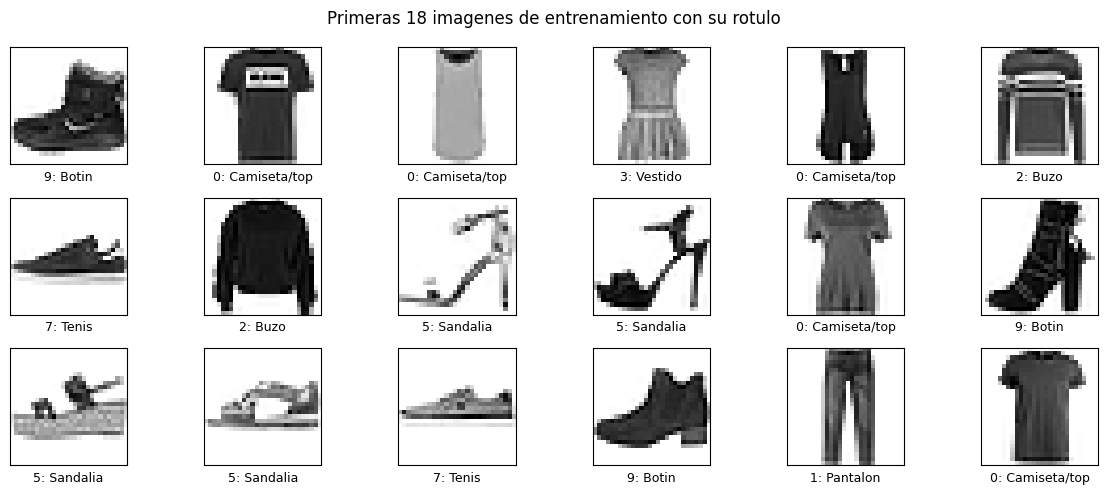

La primera imagen como matriz (solo las filas 8 a 13, columnas 0 a 13):
[[  0   0   0   0   0   0   0   0   0   1   1   1   0 200]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 183]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 193]
 [  0   0   0   0   0   0   0   0   0   1   3   0  12 219]
 [  0   0   0   0   0   0   0   0   0   0   6   0  99 244]
 [  0   0   0   0   0   0   0   0   0   4   0   0  55 236]]


In [3]:
plt.figure(figsize=(12, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.xlabel(f"{train_labels[i]}: {class_names[train_labels[i]]}", fontsize=9)
plt.suptitle("Primeras 18 imagenes de entrenamiento con su rotulo")
plt.tight_layout(); plt.show()

print("La primera imagen como matriz (solo las filas 8 a 13, columnas 0 a 13):")
print(train_images[0][8:14, :14])

**Instrucciones de esta celda.**

- `plt.figure(figsize=(12, 5))` crea una figura de 12 × 5 pulgadas.
- `plt.subplot(3, 6, i + 1)` divide la figura en una cuadrícula de 3 filas y 6 columnas y selecciona la casilla `i + 1`.
- `plt.imshow(imagen, cmap=plt.cm.binary)` dibuja la matriz como imagen; el mapa de color `binary` muestra el 0 en blanco y el 255 en negro.
- `plt.xticks([])`, `plt.yticks([])` y `plt.grid(False)` quitan los ejes y la cuadrícula, que no tienen sentido en una imagen.
- `train_images[0][8:14, :14]` usa el *slicing* de NumPy para mostrar una parte de la matriz. Es lo mismo que muestra la figura 5.14 del capítulo: para la red, una imagen no es más que una tabla de números.

## 4. Preprocesamiento: normalización y conjunto de validación

In [4]:
print("Pixel [0, 10, 14] antes:", train_images[0, 10, 14], type(train_images[0, 10, 14]).__name__)
train_images = train_images / 255.0
test_images = test_images / 255.0
print("Pixel [0, 10, 14] despues:", round(train_images[0, 10, 14], 4), train_images.dtype)

x_val, y_val = train_images[50_000:], train_labels[50_000:]
x_train, y_train = train_images[:50_000], train_labels[:50_000]
print("Entrenamiento:", x_train.shape, "  Validacion:", x_val.shape, "  Prueba:", test_images.shape)

Pixel [0, 10, 14] antes: 228 uint8
Pixel [0, 10, 14] despues: 0.8941 float64
Entrenamiento: (50000, 28, 28)   Validacion: (10000, 28, 28)   Prueba: (10000, 28, 28)


**Instrucciones de esta celda.**

- `train_images / 255.0` divide **todos** los píxeles por 255 en una sola operación (NumPy aplica la división elemento a elemento). Los valores pasan de $[0, 255]$ a $[0, 1]$ y el tipo cambia de `uint8` a `float64`.
- **¿Por qué normalizar?** La primera capa calcula $Z = W^TX + B$. Con píxeles de hasta 255, los valores de $Z$ serían cientos de veces más grandes que con píxeles entre 0 y 1, los gradientes serían enormes y el descenso del gradiente se volvería inestable. La misma operación se aplica a las imágenes de prueba, porque la red debe recibir los datos en la misma escala con la que aprendió.
- `train_images[50_000:]` toma las últimas 10 000 imágenes como **conjunto de validación**, y `train_images[:50_000]` deja las primeras 50 000 para entrenar. Es la división en tres conjuntos de la sección 5.4 del capítulo: el de validación permite vigilar el sobreentrenamiento durante el entrenamiento, y el de prueba se usa solo al final.

## 5. El modelo: `Sequential`, `Flatten` y `Dense`

In [5]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**Instrucciones de esta celda.**

- `keras.Sequential([...])` crea un modelo formado por una **lista de capas en secuencia**: la salida de cada capa es la entrada de la siguiente. Es la red *feedforward* de la figura 5.13 del capítulo, en la que la información va de la entrada a la salida sin retroalimentación.
- `keras.Input(shape=(28, 28))` declara la forma de cada ejemplo de entrada. El capítulo lo escribe como argumento de la primera capa, `Flatten(input_shape=(28, 28))`; las versiones recientes de Keras prefieren declararlo como una capa aparte. El efecto es el mismo.
- `keras.layers.Flatten()` **aplana** cada matriz de 28 × 28 en un vector de 784 valores, el vector de características $X$ del capítulo. No tiene pesos: solo reorganiza los datos.
- `keras.layers.Dense(128, activation=tf.nn.relu)` es una capa **densa** o completamente conectada: cada una de sus 128 neuronas recibe las 784 entradas. Cada neurona es la neurona artificial de la sección 5.2.2: calcula $z = \sum_j w_j x_j + b$ y le aplica la función de activación. Con todas las neuronas a la vez, en forma matricial, $A^{(1)} = g(W^{(1)T}X + B^{(1)})$. El argumento `128` es el número de neuronas; `activation="relu"` escoge la función ReLU, $g(z) = \max(0, z)$ (figura 5.7). Esta es la **capa oculta**.
- `keras.layers.Dense(10, activation="softmax")` es la **capa de salida**, con una neurona por clase y activación softmax, que convierte las 10 salidas en probabilidades.
- El capítulo escribe las activaciones como funciones, `activation=tf.nn.relu` y `activation=tf.nn.softmax`. Aquí se escriben con su nombre, `"relu"` y `"softmax"`: el cálculo es idéntico, pero con el nombre Keras puede guardar el modelo en un archivo y volver a cargarlo (sección 11), mientras que con la función de TensorFlow la carga falla porque no sabe cómo reconstruirla.
- `model.summary()` imprime las capas, la forma de su salida (`None` representa el número de ejemplos, que puede ser cualquiera) y el número de parámetros entrenables.

**Conteo de parámetros.** La capa oculta tiene una matriz $W^{(1)}$ de $784\times128$ y un vector $B^{(1)}$ de 128: $784\cdot128+128 = 100\,480$. La de salida, $128\cdot10+10 = 1\,290$. En total $101\,770$, lo que reporta `summary()`.

### 5.1 Qué hacen `Flatten`, `Dense`, ReLU y softmax: comprobación a mano

El modelo todavía no se ha entrenado, pero ya tiene pesos iniciales aleatorios y se puede aplicar a una imagen. Se repite su cálculo con NumPy:

In [6]:
x = train_images[:1]                                   # una imagen, forma (1, 28, 28)

# Flatten equivale a reorganizar la matriz con reshape
aplanada_keras = model.layers[0](x).numpy()
aplanada_numpy = x.reshape(1, 784)
print("Flatten: forma", aplanada_keras.shape, "  igual a reshape(1, 784):", np.allclose(aplanada_keras, aplanada_numpy))

# Dense + ReLU: A1 = max(0, X W1 + B1)
W1, B1 = model.layers[1].get_weights()
W2, B2 = model.layers[2].get_weights()
print("W1", W1.shape, " B1", B1.shape, " W2", W2.shape, " B2", B2.shape)
print("Pesos iniciales de W1: entre", W1.min().round(3), "y", W1.max().round(3), "  sesgos iniciales:", np.unique(B1))

Z1 = aplanada_numpy @ W1 + B1
A1 = np.maximum(0, Z1)
print(f"Capa oculta: {np.mean(Z1 < 0):.0%} de las 128 neuronas tienen z < 0 y ReLU las deja en 0")

# Dense + softmax: A2 = softmax(A1 W2 + B2)
Z2 = A1 @ W2 + B2
A2 = np.exp(Z2) / np.exp(Z2).sum()
salida_keras = model(x).numpy()
print("\nSalida de la red sin entrenar (probabilidades de las 10 clases):")
print(np.round(salida_keras, 3))
print("Suman:", salida_keras.sum().round(6), "  diferencia maxima con el calculo a mano:", np.abs(A2 - salida_keras).max())

Flatten: forma (1, 784)   igual a reshape(1, 784): True
W1 (784, 128)  B1 (128,)  W2 (128, 10)  B2 (10,)
Pesos iniciales de W1: entre -0.081 y 0.081   sesgos iniciales: [0.]
Capa oculta: 52% de las 128 neuronas tienen z < 0 y ReLU las deja en 0

Salida de la red sin entrenar (probabilidades de las 10 clases):
[[0.063 0.054 0.422 0.084 0.053 0.023 0.058 0.042 0.15  0.051]]
Suman: 1.0   diferencia maxima con el calculo a mano: 8.974188980825915e-08


- `model.layers[i]` da acceso a cada capa, y una capa se puede aplicar sola como una función: `model.layers[0](x)` es la salida de `Flatten`.
- `get_weights()` devuelve los parámetros de una capa como arreglos de NumPy: la matriz $W$ (Keras la guarda con forma `(entradas, neuronas)`, por eso se multiplica $X W$) y el vector de sesgos $B$. Keras inicializa $W$ con valores aleatorios pequeños (inicialización de Glorot) y los sesgos en cero.
- `model(x)` propaga la imagen por toda la red. Coincide con el cálculo a mano hasta el redondeo.

Sin entrenamiento, la salida no tiene relación con la imagen: en este caso la red le asigna 0.42 a *Buzo* a un botín, solo por efecto de los pesos aleatorios. Todavía no sabe nada. Entrenar es ajustar $W^{(1)}, B^{(1)}, W^{(2)}, B^{(2)}$ para que la probabilidad se concentre en la clase correcta.

## 6. La configuración del aprendizaje: `compile`

In [7]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# La perdida de la red sin entrenar, calculada por Keras y a mano, en las primeras 1000 imagenes
p = model.predict(train_images[:1000], verbose=0)
perdida_manual = -np.mean(np.log(p[np.arange(1000), train_labels[:1000]]))
perdida_keras = keras.losses.SparseCategoricalCrossentropy()(train_labels[:1000], p).numpy()
print(f"Entropia cruzada inicial: a mano = {perdida_manual:.4f}   Keras = {perdida_keras:.4f}   ln(10) = {np.log(10):.4f}")

Entropia cruzada inicial: a mano = 2.5109   Keras = 2.5109   ln(10) = 2.3026


**Instrucciones de esta celda.**

`compile` no entrena nada: define **cómo** se va a entrenar. Recibe las tres piezas del algoritmo de aprendizaje de la sección 5.5 del capítulo:

- `optimizer="adam"`: el algoritmo que actualiza los pesos. Todos los optimizadores de Keras son variantes del descenso del gradiente del capítulo, $W \leftarrow W - \eta\,\partial E/\partial W$. **Adam** guarda un promedio móvil de los gradientes recientes y de sus cuadrados, y con ellos ajusta un paso distinto para cada peso; converge más rápido que el descenso del gradiente simple (`"sgd"`). Su tasa de aprendizaje por defecto es $\eta = 0.001$.
- `loss="sparse_categorical_crossentropy"`: la **función de pérdida**. El capítulo usa el error cuadrático $E = \frac12 e^Te$; para clasificación con softmax se usa la **entropía cruzada**, $E = -\ln p_y$, donde $p_y$ es la probabilidad que la red le da a la clase correcta. Si la red asigna probabilidad 1 a la clase correcta, $E = 0$; si le asigna 0.01, $E = 4.6$. El prefijo *sparse* indica que los rótulos se entregan como enteros (9) y no como vectores *one-hot* (`[0,0,0,0,0,0,0,0,0,1]`).
- `metrics=["accuracy"]`: medidas que se reportan durante el entrenamiento pero **no** intervienen en el ajuste de los pesos. La exactitud (*accuracy*) es la fracción de imágenes cuya clase más probable coincide con el rótulo.

El cálculo a mano confirma la fórmula: la pérdida inicial calculada con $-\ln p_y$ coincide con la de Keras (2.51). Es del orden de $\ln 10 = 2.30$, que es $-\ln(0.1)$, la pérdida de una red que asigna 0.1 a cada clase; es decir, al comienzo la red no es mejor que adivinar.

### 6.1 Qué hace un paso de entrenamiento: `GradientTape`

`fit`, en la siguiente sección, repite miles de veces el mismo paso: propagar un lote, calcular la pérdida, **retropropagar** para obtener $\partial E/\partial W$ y actualizar los pesos. Para ver ese paso aislado se hace uno manualmente con `tf.GradientTape` y el descenso del gradiente simple, sobre un modelo idéntico al anterior (una copia, para no alterar el que se va a entrenar):

In [8]:
copia = keras.models.clone_model(model)
copia.set_weights(model.get_weights())
lote_x, lote_y = x_train[:32], y_train[:32]
eta = 0.1

with tf.GradientTape() as cinta:
    probs = copia(lote_x, training=True)                                     # propagacion
    E = keras.losses.sparse_categorical_crossentropy(lote_y, probs)          # perdida de cada ejemplo
    E = tf.reduce_mean(E)                                                    # promedio del lote
gradientes = cinta.gradient(E, copia.trainable_variables)                    # retropropagacion

W_antes = [v.numpy().copy() for v in copia.trainable_variables]
keras.optimizers.SGD(learning_rate=eta).apply_gradients(zip(gradientes, copia.trainable_variables))
W_despues = [v.numpy() for v in copia.trainable_variables]

for v, g, a, d in zip(copia.trainable_variables, gradientes, W_antes, W_despues):
    print(f"{v.path:<22} forma {str(tuple(v.shape)):<11} gradiente {str(tuple(g.shape)):<11}"
          f" W_nuevo = W - eta*grad: {np.allclose(d, a - eta * g.numpy(), atol=1e-7)}")
E2 = keras.losses.sparse_categorical_crossentropy(lote_y, copia(lote_x)).numpy().mean()
print(f"\nPerdida del lote antes del paso: {E.numpy():.4f}   despues: {E2:.4f}")

sequential/dense/kernel forma (784, 128)  gradiente (784, 128)  W_nuevo = W - eta*grad: True
sequential/dense/bias  forma (128,)      gradiente (128,)      W_nuevo = W - eta*grad: True
sequential/dense_1/kernel forma (128, 10)   gradiente (128, 10)   W_nuevo = W - eta*grad: True
sequential/dense_1/bias forma (10,)       gradiente (10,)       W_nuevo = W - eta*grad: True

Perdida del lote antes del paso: 2.5905   despues: 1.9953


**Instrucciones de esta celda.**

- `keras.models.clone_model` crea un modelo con la misma arquitectura, y `set_weights(model.get_weights())` le copia los pesos.
- `with tf.GradientTape() as cinta:` "graba" todas las operaciones que se hacen dentro del bloque. Con esa grabación, `cinta.gradient(E, variables)` aplica la regla de la cadena hacia atrás y devuelve $\partial E/\partial W$ para cada matriz y cada vector de sesgos. Es la **retropropagación** de la sección 5.5 del capítulo, calculada automáticamente.
- `copia.trainable_variables` es la lista de los cuatro parámetros entrenables: $W^{(1)}, B^{(1)}, W^{(2)}, B^{(2)}$. Cada gradiente tiene la misma forma que su parámetro.
- `SGD(learning_rate=eta).apply_gradients(...)` aplica la regla $W \leftarrow W - \eta\,\partial E/\partial W$. La comprobación muestra que los pesos nuevos son exactamente los anteriores menos $\eta$ por el gradiente, y la pérdida del lote baja tras un solo paso.

Esto es todo lo que hace el entrenamiento; `fit` solo lo organiza en lotes y épocas.

## 7. El entrenamiento: `fit` y los *callbacks*

In [9]:
class ResumenEpoca(keras.callbacks.Callback):
    "Callback propio: imprime una linea al terminar cada epoca."
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoca {epoch + 1:>2}: perdida = {logs['loss']:.4f}  exactitud = {logs['accuracy']:.4f}  |  "
              f"validacion: perdida = {logs['val_loss']:.4f}  exactitud = {logs['val_accuracy']:.4f}")

parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(x_val, y_val),
                    callbacks=[parada, ResumenEpoca()],
                    verbose=0)
print(f"\nEpocas ejecutadas: {len(history.history['loss'])}; mejor epoca en validacion: "
      f"{int(np.argmin(history.history['val_loss'])) + 1}")
print("Claves guardadas en history.history:", list(history.history.keys()))

Epoca  1: perdida = 0.5165  exactitud = 0.8185  |  validacion: perdida = 0.4670  exactitud = 0.8268


Epoca  2: perdida = 0.3880  exactitud = 0.8609  |  validacion: perdida = 0.4068  exactitud = 0.8490


Epoca  3: perdida = 0.3457  exactitud = 0.8729  |  validacion: perdida = 0.3829  exactitud = 0.8576


Epoca  4: perdida = 0.3184  exactitud = 0.8829  |  validacion: perdida = 0.3657  exactitud = 0.8670


Epoca  5: perdida = 0.2977  exactitud = 0.8902  |  validacion: perdida = 0.3552  exactitud = 0.8711


...

Epoca  9: perdida = 0.2426  exactitud = 0.9093  |  validacion: perdida = 0.3458  exactitud = 0.8814


Epoca 10: perdida = 0.2330  exactitud = 0.9126  |  validacion: perdida = 0.3505  exactitud = 0.8787


Epoca 11: perdida = 0.2251  exactitud = 0.9161  |  validacion: perdida = 0.3585  exactitud = 0.8780


Epoca 12: perdida = 0.2169  exactitud = 0.9189  |  validacion: perdida = 0.3533  exactitud = 0.8822



Epocas ejecutadas: 12; mejor epoca en validacion: 8
Claves guardadas en history.history: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


**Instrucciones de esta celda.**

- `model.fit(x_train, y_train, ...)` ejecuta el entrenamiento: propaga, calcula la pérdida, retropropaga y actualiza los pesos.
- `epochs=30`: número máximo de **épocas**. Una época es una pasada completa por los 50 000 ejemplos de entrenamiento.
- `batch_size=32`: los pesos se actualizan después de cada **lote** de 32 imágenes, no después de cada imagen ni de las 50 000. Por época hay $\lceil 50\,000/32\rceil = 1\,563$ actualizaciones. A esto se le llama descenso del gradiente por mini-lotes; el gradiente de un lote es una estimación del gradiente de todo el conjunto, mucho más barata de calcular.
- `validation_data=(x_val, y_val)`: al final de cada época se evalúa el modelo en el conjunto de validación, que **nunca** se usa para ajustar los pesos.
- `callbacks=[...]`: lista de objetos que Keras llama en momentos definidos del entrenamiento.
  - `EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)` vigila la pérdida de validación; si no mejora durante 4 épocas seguidas, detiene el entrenamiento y restaura los pesos de la mejor época. Evita el sobreentrenamiento de la figura 5.12 sin tener que adivinar el número de épocas.
  - `ResumenEpoca` es un *callback* propio: una clase que hereda de `keras.callbacks.Callback` y redefine el método `on_epoch_end`, que Keras llama al final de cada época con las métricas en el diccionario `logs`. Hay otros métodos disponibles, como `on_train_begin` o `on_batch_end`.
- `verbose=0` desactiva la barra de progreso de Keras, ya que el *callback* imprime su propio resumen.
- `fit` devuelve un objeto `History`; su atributo `history` es un diccionario con la lista de valores de cada métrica por época.

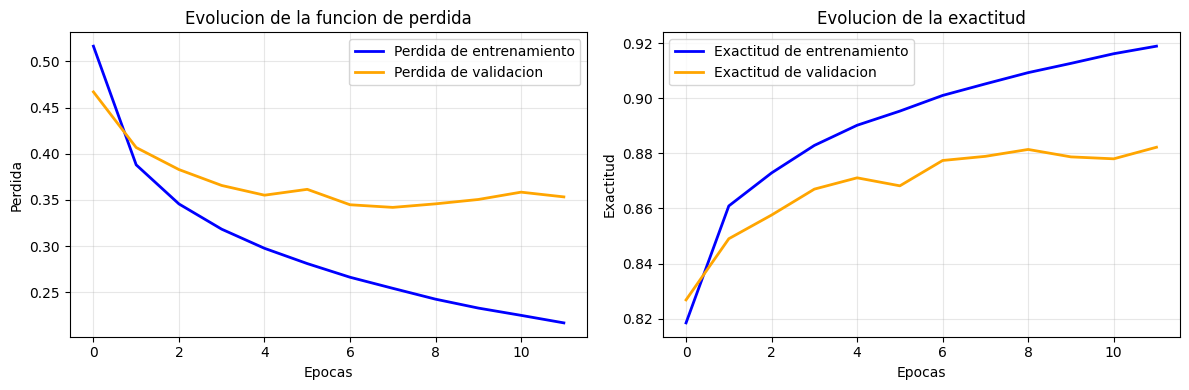

In [10]:
h = history.history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h["loss"], label="Perdida de entrenamiento", color="blue", linewidth=2)
plt.plot(h["val_loss"], label="Perdida de validacion", color="orange", linewidth=2)
plt.title("Evolucion de la funcion de perdida"); plt.xlabel("Epocas"); plt.ylabel("Perdida"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(h["accuracy"], label="Exactitud de entrenamiento", color="blue", linewidth=2)
plt.plot(h["val_accuracy"], label="Exactitud de validacion", color="orange", linewidth=2)
plt.title("Evolucion de la exactitud"); plt.xlabel("Epocas"); plt.ylabel("Exactitud"); plt.legend()
plt.tight_layout(); plt.show()

**Instrucciones de esta celda.** Son las mismas instrucciones de graficación que usa el capítulo para la figura de la pérdida: `plt.plot(history.history['loss'], label=..., color=..., linewidth=...)` dibuja la lista de pérdidas por época, `plt.title`, `plt.xlabel` y `plt.ylabel` ponen los rótulos, `plt.legend()` la leyenda y `plt.show()` muestra la figura. Aquí se agregan las curvas de validación, que permiten detectar el sobreentrenamiento.

**Lo que muestran las curvas.** En la primera época la exactitud de validación ya es de 82.7 %, y la mejor época es la 8 (pérdida de validación de 0.342, exactitud de 87.9 %). A partir de allí la pérdida de entrenamiento sigue bajando, pero la de validación sube: es el **sobreentrenamiento** que describen las figuras 5.12 y 5.17 del capítulo. `EarlyStopping` esperó 4 épocas sin mejora, detuvo el entrenamiento en la época 12 y restauró los pesos de la época 8.

## 8. Prueba del modelo: `evaluate`

In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Perdida en prueba: {test_loss:.4f}")
print(f"Exactitud en prueba: {test_acc:.4f}  ({round(test_acc * len(test_labels))} de {len(test_labels)} imagenes)")

Perdida en prueba: 0.3575
Exactitud en prueba: 0.8738  (8738 de 10000 imagenes)


**Instrucciones de esta celda.** `model.evaluate(x, y)` propaga todas las imágenes de prueba, sin modificar los pesos, y devuelve la pérdida y las métricas declaradas en `compile`, en ese orden. Es la estimación del desempeño del modelo en el mundo real, porque la red nunca vio estas imágenes ni se usaron para tomar ninguna decisión.

La red del capítulo, con una capa oculta de 128 neuronas, clasifica correctamente **el 87.4 %** de las prendas de prueba (8 738 de 10 000). La exactitud de prueba es algo menor que la de entrenamiento en la época 8 (90.5 %), como es normal, y cercana a la de validación (87.9 %), lo que indica que el conjunto de validación dio una buena estimación del desempeño real.

## 9. Predicción: `predict` y `argmax`

In [12]:
predictions = model.predict(test_images, verbose=0)
print("Forma de predictions:", predictions.shape)
print("Probabilidades para la primera imagen de prueba:\n", np.round(predictions[0], 4))
print("Clase predicha: np.argmax ->", np.argmax(predictions[0]), f"({class_names[np.argmax(predictions[0])]})",
      "   rotulo real:", test_labels[0], f"({class_names[test_labels[0]]})")

# Prediccion de una sola imagen: Keras siempre espera un lote, por eso se agrega una dimension
img = test_images[7]
print("\nForma de una imagen:", img.shape, " -> con np.expand_dims:", np.expand_dims(img, 0).shape)
p7 = model.predict(np.expand_dims(img, 0), verbose=0)[0]

# La misma prediccion, a mano, con los pesos entrenados
W1, B1, W2, B2 = model.get_weights()
a1 = np.maximum(0, img.reshape(784) @ W1 + B1)
z2 = a1 @ W2 + B2
a2 = np.exp(z2 - z2.max()) / np.exp(z2 - z2.max()).sum()
print(f"Imagen 7: red -> {class_names[p7.argmax()]} ({p7.max():.2%})   real -> {class_names[test_labels[7]]}")
print("Diferencia maxima entre model.predict y el calculo a mano:", np.abs(a2 - p7).max())

Forma de predictions: (10000, 10)
Probabilidades para la primera imagen de prueba:
 [0.     0.     0.     0.     0.     0.0223 0.     0.0043 0.     0.9734]
Clase predicha: np.argmax -> 9 (Botin)    rotulo real: 9 (Botin)

Forma de una imagen: (28, 28)  -> con np.expand_dims: (1, 28, 28)
Imagen 7: red -> Camisa (99.80%)   real -> Camisa
Diferencia maxima entre model.predict y el calculo a mano: 1.930492710133791e-08


**Instrucciones de esta celda.**

- `model.predict(x)` devuelve, para cada imagen, las 10 salidas de la capa softmax: una matriz de $10\,000\times10$ en la que cada fila suma 1. Es el vector $H_w(X)$ del capítulo.
- `np.argmax(v)` devuelve la **posición** del mayor valor del vector, es decir, la clase más probable. Con `class_names[...]` se traduce a su nombre.
- Keras procesa siempre **lotes** de ejemplos. Para predecir una sola imagen de forma `(28, 28)` hay que convertirla en un lote de una imagen, de forma `(1, 28, 28)`, con `np.expand_dims(img, 0)`.
- La predicción calculada a mano con los pesos entrenados coincide con la de `predict`: la red entrenada es exactamente $A^{(2)} = \text{softmax}(W^{(2)T}\,\text{ReLU}(W^{(1)T}X + B^{(1)}) + B^{(2)})$.

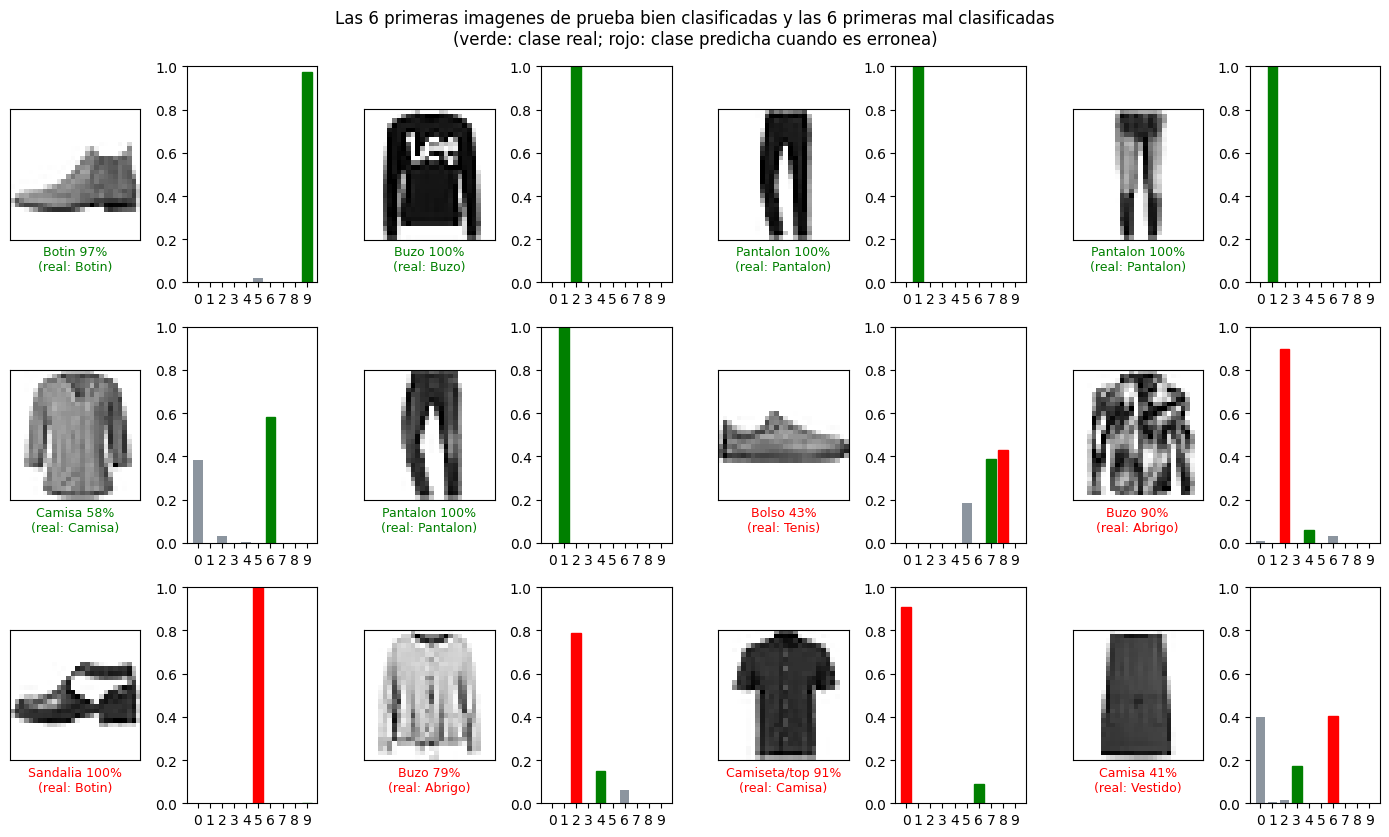

In [13]:
def dibuja(i):
    color = "green" if predictions[i].argmax() == test_labels[i] else "red"
    plt.imshow(test_images[i], cmap=plt.cm.binary); plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.xlabel(f"{class_names[predictions[i].argmax()]} {predictions[i].max():.0%}\n(real: {class_names[test_labels[i]]})",
               color=color, fontsize=9)

def barras(i):
    b = plt.bar(range(10), predictions[i], color="#8c959f")
    plt.ylim(0, 1); plt.xticks(range(10)); plt.grid(False)
    b[predictions[i].argmax()].set_color("red"); b[test_labels[i]].set_color("green")

clase = predictions.argmax(axis=1)
muestra = np.r_[np.where(clase == test_labels)[0][:6], np.where(clase != test_labels)[0][:6]]
filas, columnas = 3, 4
plt.figure(figsize=(14, 8.5))
for k, i in enumerate(muestra):
    plt.subplot(filas, 2 * columnas, 2 * k + 1); dibuja(i)
    plt.subplot(filas, 2 * columnas, 2 * k + 2); barras(i)
plt.suptitle("Las 6 primeras imagenes de prueba bien clasificadas y las 6 primeras mal clasificadas\n(verde: clase real; rojo: clase predicha cuando es erronea)")
plt.tight_layout(); plt.show()

**Instrucciones de esta celda.** Se definen dos funciones auxiliares con `def`: `dibuja` muestra la imagen con la clase predicha, su probabilidad y la clase real, en verde si acierta y en rojo si falla; `barras` dibuja con `plt.bar` las 10 probabilidades, coloreando de verde la clase real y de rojo la predicha cuando son distintas. Con `np.where` se buscan las posiciones de las imágenes bien y mal clasificadas, y `np.r_` une las dos listas para mostrar seis de cada tipo.

Cinco de los seis aciertos tienen probabilidades de 97 % a 100 %; la excepción es una camisa, acertada con solo 58 % frente a 38 % de camiseta. En los errores se ven dos situaciones distintas. En algunos la red duda: un tenis al que asigna 43 % de bolso y 38 % de tenis, o un vestido con probabilidades cercanas al 40 % para camisa y para camiseta. En otros se equivoca con mucha seguridad: un botín clasificado como sandalia con probabilidad cercana al 100 %, una camisa como camiseta con 91 % y un abrigo como buzo con 90 %. Son imágenes que, a esta resolución, se parecen más a otra clase que a la suya.

## 10. Matriz de confusión: `tf.math.confusion_matrix`

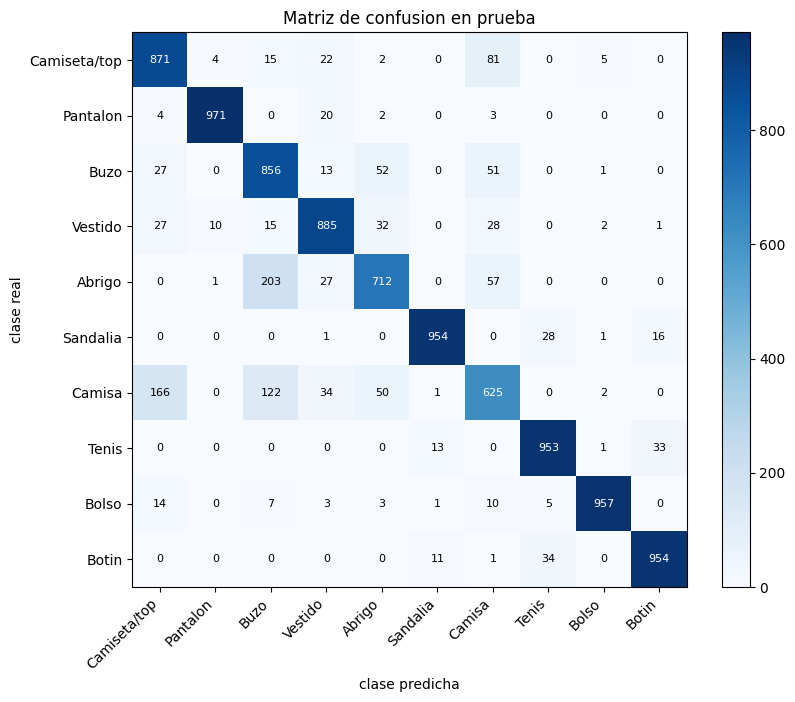

Clase          aciertos
Camisa            62.5%
Abrigo            71.2%
Buzo              85.6%
Camiseta/top      87.1%
Vestido           88.5%
Tenis             95.3%
Sandalia          95.4%
Botin             95.4%
Bolso             95.7%
Pantalon          97.1%


In [14]:
pred = predictions.argmax(axis=1)
cm = tf.math.confusion_matrix(test_labels, pred).numpy()
plt.figure(figsize=(8.5, 7))
plt.imshow(cm, cmap="Blues")
for (r, c), v in np.ndenumerate(cm):
    plt.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > 500 else "black")
plt.xticks(range(10), class_names, rotation=45, ha="right"); plt.yticks(range(10), class_names)
plt.xlabel("clase predicha"); plt.ylabel("clase real"); plt.grid(False); plt.colorbar()
plt.title("Matriz de confusion en prueba"); plt.tight_layout(); plt.show()

print(f"{'Clase':<14}{'aciertos':>9}")
for c in np.argsort(np.diag(cm)):
    print(f"{class_names[c]:<14}{cm[c, c] / cm[c].sum():>9.1%}")

**Instrucciones de esta celda.** `tf.math.confusion_matrix(reales, predichas)` construye una tabla de $10\times10$ en la que la fila es la clase real y la columna la clase predicha; la diagonal son los aciertos. `np.diag(cm)` extrae la diagonal y `np.argsort` ordena las clases de la más difícil a la más fácil.

Los errores se concentran en las prendas superiores: la camisa es la clase más difícil (62.5 % de aciertos), seguida del abrigo (71.2 %), mientras que pantalón, bolso, botín, sandalia y tenis superan el 95 %. Las prendas con siluetas características se reconocen casi siempre; las que se distinguen por detalles pequeños (cuello, botones, largo) se confunden entre sí.

## 11. Guardar y cargar el modelo: `save` y `load_model`

In [15]:
model.save("modelo_fashion.keras")
print("Tamano del archivo:", round(os.path.getsize("modelo_fashion.keras") / 1024), "KB")
recuperado = keras.models.load_model("modelo_fashion.keras")
print("Predicciones identicas despues de cargar:", np.array_equal(recuperado.predict(test_images, verbose=0).argmax(1), pred))
os.remove("modelo_fashion.keras")

Tamano del archivo: 1215 KB


Predicciones identicas despues de cargar: True


**Instrucciones de esta celda.** `model.save("archivo.keras")` guarda en un solo archivo la arquitectura, los pesos entrenados y la configuración de `compile`. `keras.models.load_model` lo reconstruye, listo para predecir sin volver a entrenar. Es la forma de llevar un modelo entrenado a otra aplicación (por ejemplo, un robot que clasifique objetos). Al final se borra el archivo con `os.remove` para no dejar residuos.

## 12. Resumen de las funciones utilizadas

| Función o instrucción | Qué hace | Relación con el capítulo |
|---|---|---|
| `keras.datasets.fashion_mnist.load_data()` | descarga y devuelve `(x_train, y_train), (x_test, y_test)` | conjunto de pares $(X^{(i)}, Y^{(i)})$ |
| `imagenes / 255.0` | normaliza los píxeles a $[0, 1]$ | escala de las características |
| `keras.Sequential([...])` | modelo de capas en secuencia | red *feedforward*, figura 5.13 |
| `keras.Input(shape=...)` | declara la forma de la entrada | capa 0, $A^{(0)} = X$ |
| `layers.Flatten()` | matriz 28 × 28 → vector de 784 | vector de características $X$ |
| `layers.Dense(n, activation=g)` | $A = g(W^TA_{prev} + B)$ con $n$ neuronas | neurona artificial, sección 5.2.2 |
| `"relu"` (`tf.nn.relu`) | $\max(0, z)$ | función ReLU, figura 5.7 |
| `"softmax"` (`tf.nn.softmax`) | $e^{z_j}/\sum_i e^{z_i}$, probabilidades que suman 1 | salida de multi-clasificación, $k = 10$ |
| `model.summary()` | capas, formas y número de parámetros | dimensiones de $W$ y $B$ |
| `layer.get_weights()`, `model.get_weights()` | matrices $W$ y vectores $B$ como arreglos de NumPy | matriz de pesos de cada capa |
| `model.compile(optimizer, loss, metrics)` | configura el aprendizaje | sección 5.5 |
| `"adam"`, `SGD(learning_rate)` | reglas de actualización de los pesos | $W \leftarrow W - \eta\,\partial E/\partial W$ |
| `"sparse_categorical_crossentropy"` | $E = -\ln p_y$ | función de pérdida |
| `tf.GradientTape`, `tape.gradient` | derivadas automáticas por la regla de la cadena | *backpropagation* |
| `optimizer.apply_gradients` | aplica un paso de descenso del gradiente | actualización de los pesos |
| `model.fit(x, y, epochs, batch_size, validation_data, callbacks)` | ciclo de épocas y lotes | proceso de aprendizaje |
| `callbacks.EarlyStopping` | detiene cuando la validación deja de mejorar | sobreentrenamiento, figura 5.12 |
| `callbacks.Callback`, `on_epoch_end` | código propio al final de cada época | seguimiento del entrenamiento |
| `history.history` | pérdida y métricas por época | figura de la función de pérdida |
| `model.evaluate(x, y)` | pérdida y exactitud sin tocar los pesos | conjunto de prueba |
| `model.predict(x)` | probabilidades de salida | $H_w(X)$ |
| `np.argmax`, `np.expand_dims` | clase más probable; lote de una imagen | clasificación |
| `tf.math.confusion_matrix` | tabla real × predicho | análisis de errores |
| `model.save`, `keras.models.load_model` | guardar y recuperar el modelo entrenado | uso del modelo |

## 13. Conclusiones

1. **Con unas quince instrucciones de Keras se construye, entrena y evalúa un clasificador de imágenes.** La red del capítulo (784‑128‑10) clasifica correctamente el 87.4 % de las prendas de prueba, frente al 10 % que se obtendría al azar.
2. **Cada función corresponde a una ecuación del capítulo, y se comprobó a mano.** `Flatten` es un `reshape`; `Dense` es $g(W^TX + B)$, la neurona artificial de la sección 5.2.2 aplicada a muchas neuronas a la vez; la pérdida es $-\ln p_y$; un paso de entrenamiento es $W \leftarrow W - \eta\,\partial E/\partial W$; y `predict` es la propagación de la sección 5.4. En todos los casos el cálculo hecho con NumPy coincide con el de TensorFlow.
3. **Lo que TensorFlow automatiza es la retropropagación.** `GradientTape` obtiene los gradientes de todos los pesos aplicando la regla de la cadena, sin que haya que derivar las ecuaciones de la sección 5.5 para cada arquitectura. Eso es lo que permite probar redes distintas cambiando una línea.
4. **Separar los datos en tres conjuntos no es un trámite.** El conjunto de validación detectó el sobreentrenamiento desde la época 8, `EarlyStopping` lo evitó automáticamente, y la exactitud de validación (87.9 %) anticipó bien la de prueba (87.4 %).
5. **La red se equivoca sobre todo con prendas parecidas**, camisas, abrigos y buzos, y a veces lo hace con mucha seguridad. La probabilidad de softmax no garantiza que la respuesta sea correcta.
6. **Detalles prácticos.** Los píxeles deben normalizarse igual en entrenamiento y en prueba; `predict` espera siempre un lote, así que una imagen sola necesita `np.expand_dims`; y las activaciones deben indicarse por su nombre para que el modelo se pueda guardar y cargar con `save` y `load_model`.